# Verifikasi & Validasi Data Telemetri Testbed ClarkNet

Notebook ini berfungsi untuk melakukan pencocokan (*validation check*) antara beban kerja asli dari **ClarkNet Dataset** (yang disimulasikan oleh generator beban) dengan data metrik riil yang terekam di **Prometheus** dan disimpan dalam berkas `collected_metrics.csv`.

Metodologi ini digunakan untuk membuktikan keabsahan (*validity*) data latih sebelum disuplai ke model LSTM/GRU untuk auto-scaling proactive.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data
df_collected = pd.read_csv('collected_metrics.csv')
df_original = pd.read_csv('dataset/aggregated_clarknet_rps.csv')

print(f"Data hasil ekstraksi Prometheus: {len(df_collected)} baris")
print(f"Data dataset ClarkNet asli: {len(df_original)} baris")

Data hasil ekstraksi Prometheus: 300 baris
Data dataset ClarkNet asli: 604707 baris


## 2. Hitung Statistik & Akurasi Pengiriman Beban

Kita bandingkan total request yang dikirimkan vs total request yang tersimpan secara kumulatif.

In [2]:
# Kita asumsikan pengujian memakai jendela waktu (misalnya 5 menit = 300 detik)
duration = len(df_collected)

# Karena interval scraping Prometheus dan query evaluation, terdapat lag (selisih waktu) 2 detik
# antara pengiriman request oleh load generator dan pencatatan oleh Prometheus.
# Kita lakukan alignment (shift) sebesar 2 detik untuk perbandingan detik-ke-detik yang presisi.
lag_shift = 2
compare_duration = duration - lag_shift
start_offset = 401022

orig_slice = df_original.iloc[start_offset:start_offset + compare_duration].copy()

# Ambil slice data yang sudah di-align
orig_media = orig_slice['Media_Service'].values
coll_media = df_collected['rps_media'].iloc[lag_shift:lag_shift + compare_duration].values

orig_content = orig_slice['Content_Service'].values
coll_content = df_collected['rps_content'].iloc[lag_shift:lag_shift + compare_duration].values

# Hitung akurasi per detik:
# Akurasi(t) = 1 - (|original(t) - collected(t)| / max(original(t), 1))
acc_per_sec_media = (1 - np.abs(orig_media - coll_media) / np.maximum(orig_media, 1)) * 100
acc_per_sec_content = (1 - np.abs(orig_content - coll_content) / np.maximum(orig_content, 1)) * 100

mean_acc_media = np.mean(acc_per_sec_media)
mean_acc_content = np.mean(acc_per_sec_content)

print("=== ANALISIS AKURASI TRAFIK PER DETIK (ALIGNED) ===")
print(f"Media Service - Rerata Akurasi Per Detik: {mean_acc_media:.2f}%")
print(f"Content Service - Rerata Akurasi Per Detik: {mean_acc_content:.2f}%")

# Hitung juga total kumulatif request untuk validasi volume total
total_media_sent = orig_media.sum()
total_media_rec = coll_media.sum()
total_content_sent = orig_content.sum()
total_content_rec = coll_content.sum()
print(f"\n=== VALIDASI VOLUME TOTAL ===")
print(f"Media Service - Total Sent: {total_media_sent} | Recorded: {total_media_rec:.0f}")
print(f"Content Service - Total Sent: {total_content_sent} | Recorded: {total_content_rec:.0f}")


=== ANALISIS AKURASI TRAFIK PER DETIK (ALIGNED) ===
Media Service - Rerata Akurasi Per Detik: 99.62%
Content Service - Rerata Akurasi Per Detik: 97.04%

=== VALIDASI VOLUME TOTAL ===
Media Service - Total Sent: 1625 | Recorded: 1625
Content Service - Total Sent: 380 | Recorded: 381


## 3. Visualisasi Grafik Perbandingan RPS (Actual vs Dataset)

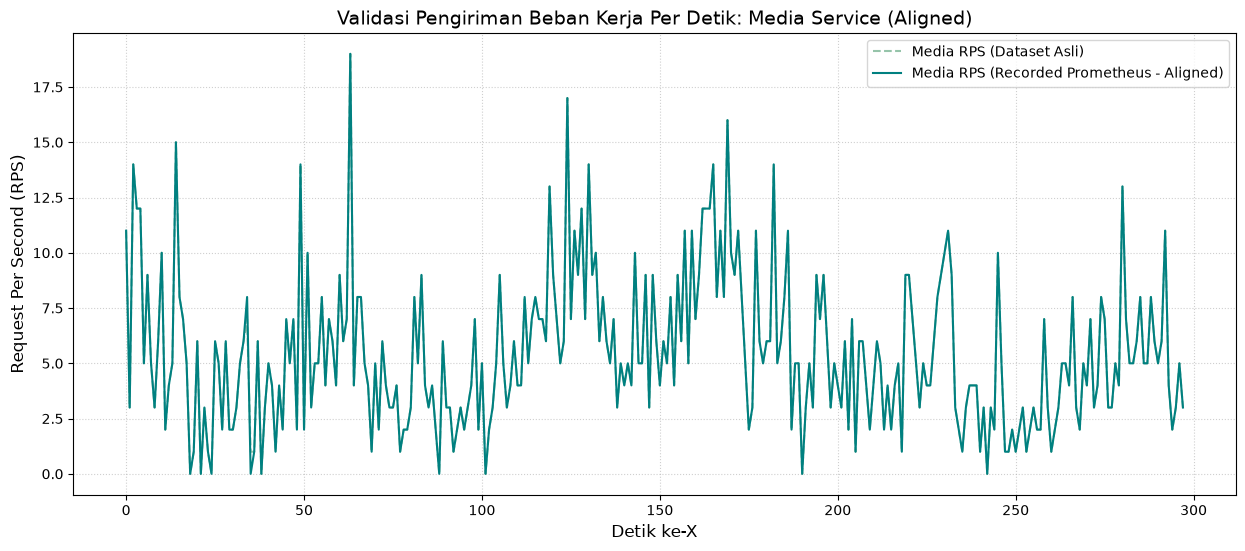

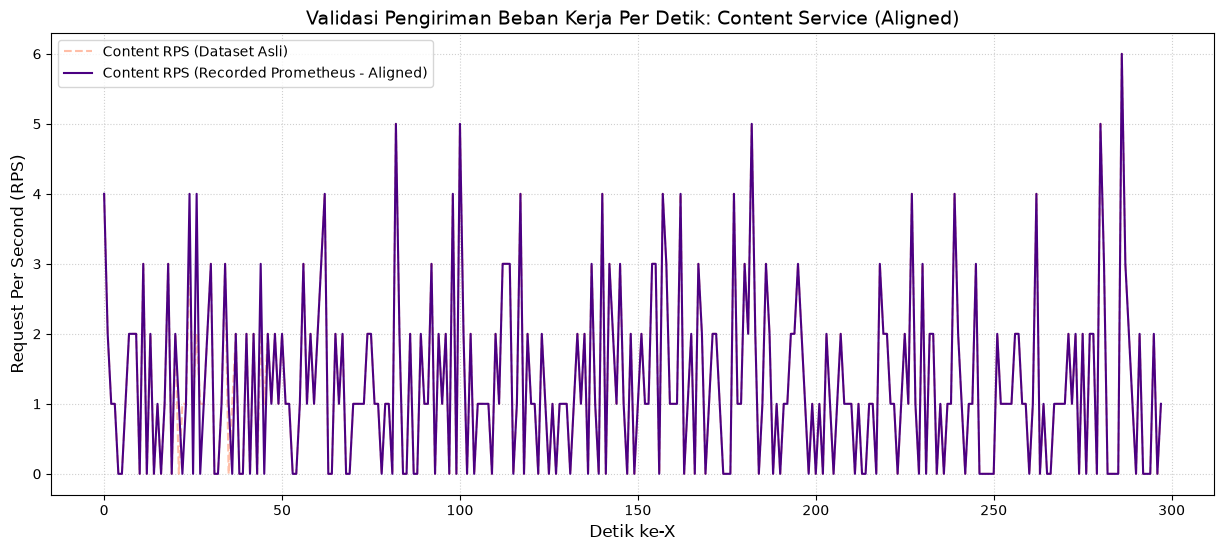

In [3]:
plt.figure(figsize=(15, 6))
# Visualisasi dengan alignment 2 detik
plt.plot(orig_media, label='Media RPS (Dataset Asli)', color='seagreen', alpha=0.5, linestyle='--')
plt.plot(coll_media, label='Media RPS (Recorded Prometheus - Aligned)', color='teal')

plt.title('Validasi Pengiriman Beban Kerja Per Detik: Media Service (Aligned)', fontsize=14)
plt.xlabel('Detik ke-X', fontsize=12)
plt.ylabel('Request Per Second (RPS)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(orig_content, label='Content RPS (Dataset Asli)', color='coral', alpha=0.5, linestyle='--')
plt.plot(coll_content, label='Content RPS (Recorded Prometheus - Aligned)', color='indigo')

plt.title('Validasi Pengiriman Beban Kerja Per Detik: Content Service (Aligned)', fontsize=14)
plt.xlabel('Detik ke-X', fontsize=12)
plt.ylabel('Request Per Second (RPS)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 4. Visualisasi Penggunaan CPU & RAM vs Lonjakan RPS

Membuktikan adanya korelasi positif antara peningkatan trafik dengan pemakaian resource kontainer.

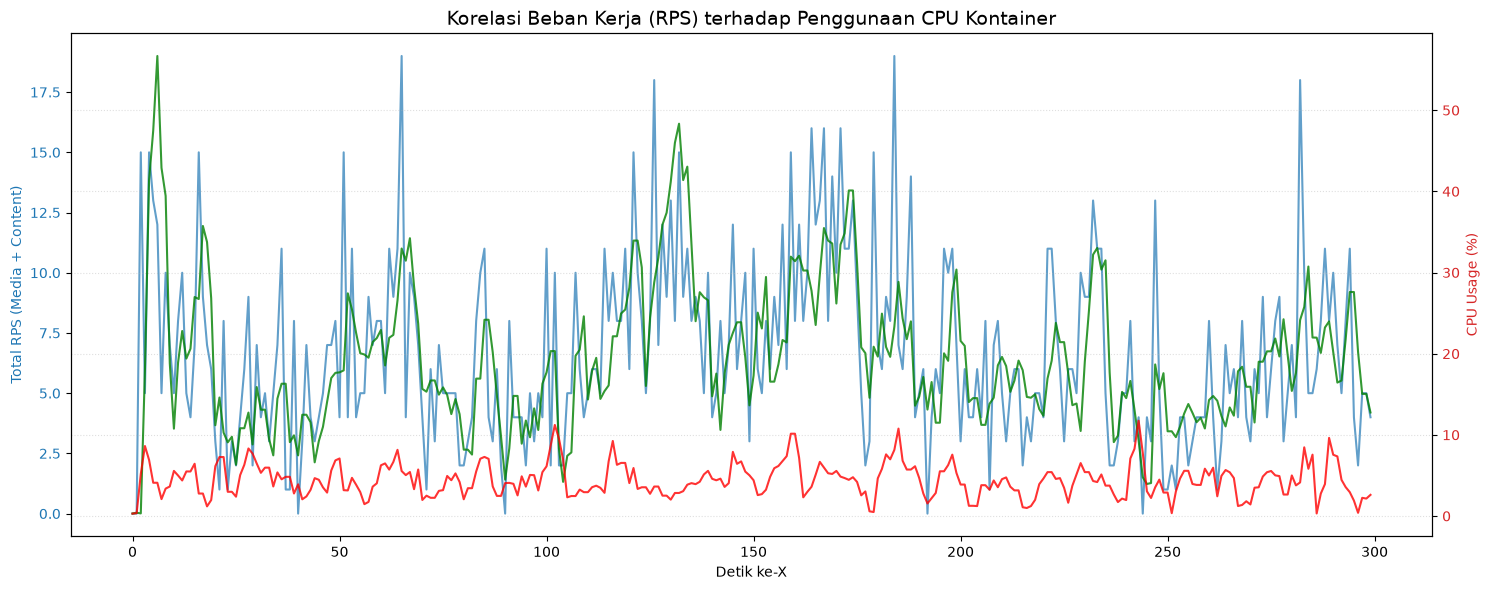

In [4]:
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Detik ke-X')
ax1.set_ylabel('Total RPS (Media + Content)', color=color)
total_rps = df_collected['rps_media'] + df_collected['rps_content']
ax1.plot(total_rps.values, color=color, alpha=0.7, label='RPS Gabungan')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('CPU Usage (%)', color=color)
ax2.plot(df_collected['cpu_media'].values, color='green', alpha=0.8, label='CPU Media')
ax2.plot(df_collected['cpu_content'].values, color='red', alpha=0.8, label='CPU Content')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Korelasi Beban Kerja (RPS) terhadap Penggunaan CPU Kontainer', fontsize=14)
fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()